# Figure 2E iPSC Dilution Graphic

Notes:

1. Singlets

In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import seaborn as sns
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.optimize import fsolve
import re
from matplotlib.patches import Patch

## Load data

In [12]:
# Directories
df_dil_dir = rd.datadir /'data'/'attune'/'Albert'/'DesNb'/ "Dilution" / "export_singlets"

# Store all df_OR in list of dfs which will be converted to df at end
df_dil = list()
# ctrl_df_OR = list()
files = Path(df_dil_dir).glob('*.csv')

# df_OR path
cache_path = rd.rootdir/'output'/'Figure_2E'/'data.gzip'
output_path = rd.rootdir /'output'/'Figure_2E'


if cache_path.exists():

    df_dil = pd.read_parquet(rd.outfile(cache_path))

else: 

    for i, file in enumerate(files):

        print(file.name)

        # Extract metadf_OR from csv title
        match = re.search(
            'export_(?P<cond>.+)_(?P<select>.+)_(?P<rep>\d)_(?P<subsetName>.+).csv', file.name)
        
        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')
        select = match.group('select')
        rep = match.group('rep')
        subsetName = match.group('subsetName')


        # Load as df and note header is on 0th row
        flow_df = pd.read_csv(file, header=0)

        # Update columns in df with metadf_OR from file name
        flow_df['cond'] = cond
        flow_df['select'] = select
        flow_df['rep'] = int(rep)
        flow_df['subsetName'] = subsetName
        
        df_dil.append(flow_df)

    # Convert list of dfs into single df
    df_dil = pd.concat(df_dil, ignore_index=True)

    # Shorten df
    channel_list = ['FSC-A', 'SSC-A','mGreenLantern-A','mGreenLantern-H', 'cond', 'select', 'rep', 'subsetName']
    df_dil = df_dil.loc[:, channel_list]
    # Rename FP channels
    df_dil.rename(columns={'mGreenLantern-A': 'EGFP-A', 'mGreenLantern-H':'EGFP-H'}, inplace=True)

    # Save shortened df
    df_dil.to_parquet(rd.outfile(cache_path))


<>:26: SyntaxWarning: invalid escape sequence '\d'
<>:26: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_11668\1014661271.py:26: SyntaxWarning: invalid escape sequence '\d'
  'export_(?P<cond>.+)_(?P<select>.+)_(?P<rep>\d)_(?P<subsetName>.+).csv', file.name)


export_50_Post_1_Singlets.csv
export_50_Post_2_Singlets.csv
export_50_Post_3_Singlets.csv
export_50_Pre_1_Singlets.csv
export_50_Pre_2_Singlets.csv
export_50_Pre_3_Singlets.csv
export_75_Post_1_Singlets.csv
export_75_Post_2_Singlets.csv
export_75_Post_3_Singlets.csv
export_75_Pre_1_Singlets.csv
export_75_Pre_2_Singlets.csv
export_75_Pre_3_Singlets.csv
export_95_Post_1_Singlets.csv
export_95_Post_2_Singlets.csv
export_95_Post_3_Singlets.csv
export_95_Pre_1_Singlets.csv
export_95_Pre_2_Singlets.csv
export_95_Pre_3_Singlets.csv
export_99.9_Post_1_Singlets.csv
export_99.9_Post_2_Singlets.csv
export_99.9_Post_3_Singlets.csv
export_99.9_Pre_1_Singlets.csv
export_99.9_Pre_2_Singlets.csv
export_99.9_Pre_3_Singlets.csv
export_99_Post_1_Singlets.csv
export_99_Post_2_Singlets.csv
export_99_Post_3_Singlets.csv
export_99_Pre_1_Singlets.csv
export_99_Pre_2_Singlets.csv
export_99_Pre_3_Singlets.csv
export_Ctrl-neg_Pre_1_Singlets.csv
export_Ctrl-neg_Pre_2_Singlets.csv


## EGFP gate

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

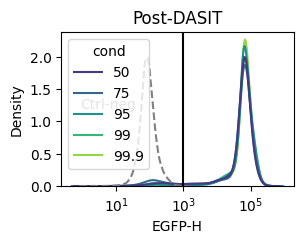

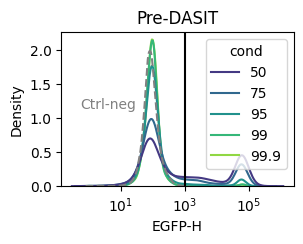

In [13]:
# Threshold for transfect
EGFP_H_thresh = 1e3

# Plotting parameters
x = 'EGFP-H'
hue = 'cond'
hue_order = ["50", "75", "95", "99", "99.9"]
palette = 'viridis'

# Plot
for select in df_dil.select.unique():
    fig, ax = plt.subplots(1, 1, figsize=(3, 2))
    sns.kdeplot(data=df_dil[(df_dil[x]>0) & (df_dil['select']==select)],
            ax=ax, x=x, hue=hue, hue_order=hue_order,
            common_norm=False, log_scale=(True, False), palette=palette,
            fill=False)

    # Plot ctrl-neg
    sns.kdeplot(data=df_dil.loc[(df_dil['cond'] == 'Ctrl-neg') & (df_dil[x]>0)],
            ax=ax, x=x,
            common_norm=False, log_scale=(True, False),
            fill=False, linestyle='--', color='grey')
    ax.annotate('Ctrl-neg', (0.2, 0.5), color='grey', xycoords='axes fraction', ha='center')

    # Plot threshold
    ax.axvline(EGFP_H_thresh, 0, 1, color='black')

    # Format
    plt.title(f'{select}-DASIT')

In [15]:
# Categorize cells 
df_dil['EGFP_cat'] = np.where(df_dil['EGFP-H'] > EGFP_H_thresh, 'EGFP+', 'EGFP-') 

# Get total counts and percent of GFP-H+
group = ['cond', 'select', 'rep']
count_df_reps = df_dil.groupby([*group, 'EGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
# Puts 0 if no GFP-H+ rather than dropping row
df_dil_percent = (count_df_reps*100/count_df_reps.groupby([*group]).transform('sum')).reset_index(name='percent')

# Extract just the eGFP+
df_dil_percent = df_dil_percent.loc[(df_dil_percent['EGFP_cat'] == 'EGFP+')]

**Figure 2E**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_11668\2896363860.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site

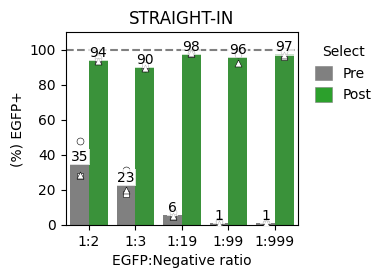

In [19]:
# General plotting params
x = 'cond'
y = 'percent'
hue = 'select'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
hue_order = ['Pre', 'Post']
order = ["50", "75", "95", "99", "99.9"]
palette = {'Pre': 'grey', 'Post':'tab:green'}


label_dict = {"50": '1:2', "75": '1:3', "95":'1:19', "99": "1:99", "99.9": "1:999"}

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

# Plot
sns.barplot(
    ax=ax, data=df_dil_percent,
    x=x, y=y, ci=None, hue=hue,
    order=order,
    hue_order=hue_order,
    palette=palette, alpha=1)

# Plot tech reps
for (j, rep) in enumerate(df_dil_percent.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_dil_percent[(df_dil_percent.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,)
    
# Formatting
ax.yaxis.set_label_text('(%) EGFP+')
ax.set_ylim((0, 110))
# h,l = ax.get_legend_handles_labels()
# legend_dict = {'Pre': 'Pre-DAST', 'Post': 'Post-DASIT'}
# sns.move_legend(ax, handles=h[-len(hue_order):], labels=[legend_dict[leg] for leg in l[-len(hue_order):]],
#     title=f'', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

legend_elements = [
    Patch(facecolor='grey', edgecolor='grey', linewidth=0.4,
          label='Pre'),
    Patch(facecolor='tab:green', edgecolor='grey', linewidth=0.4,
          label='Post')
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_elements,
    title='Select',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)


ax.set_xticklabels([label_dict[l] for l in order])

# Title
ax.set_title(f'STRAIGHT-IN')
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('EGFP:Negative ratio')
# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=0)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))

plottitle = f'Figure_2E_DASIT.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')  
